# 2. Threshold values

In this chapter a threshold discharge will be determined by connecting historical droughts in the Okavango Delta with the discharge data at Mohembo (DEAfrica Team, 2021). Figure 2.1 below shows the location of Mohembo with respect to the Okavango Delta (Alamy, 2026). First, the discharge data will be analyzed, and threshold values will be determined for years that clearly show lower values. The data used in this study comes from Digital Earth Africa (DEAfrica Team, 2021). After the analysis, the years that fall below the threshold values will be connected with the historic dry years mentioned in the introduction. Lastly, the droughts will be categorized based on quantile values. 2 

<figure>
  <img src="Figures/LocationMohembo.png" width="400">
  <figcaption><i>Figure 2.1: location of Mohembo (Alamy, n.d.)</i></figcaption>
</figure>

## 2.1 Discharge data analysis
The biggest problems occur when the Okavango Delta experiences droughts in the flood season, as the wildlife moves towards the delta in this period for the floodplains. In figure 2.2 with the data from DEAfrica Team (2021), the discharge variability during the year that is causing the flood season can be clearly seen. The peak flood season occurs between May and September (Gaudaré, et al., 2025). The Okavango River discharge peaks at Mohembo between February and July causing the flooding between May and September, as displayed in figure 2.3. 

In [1]:
#Loading packages
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

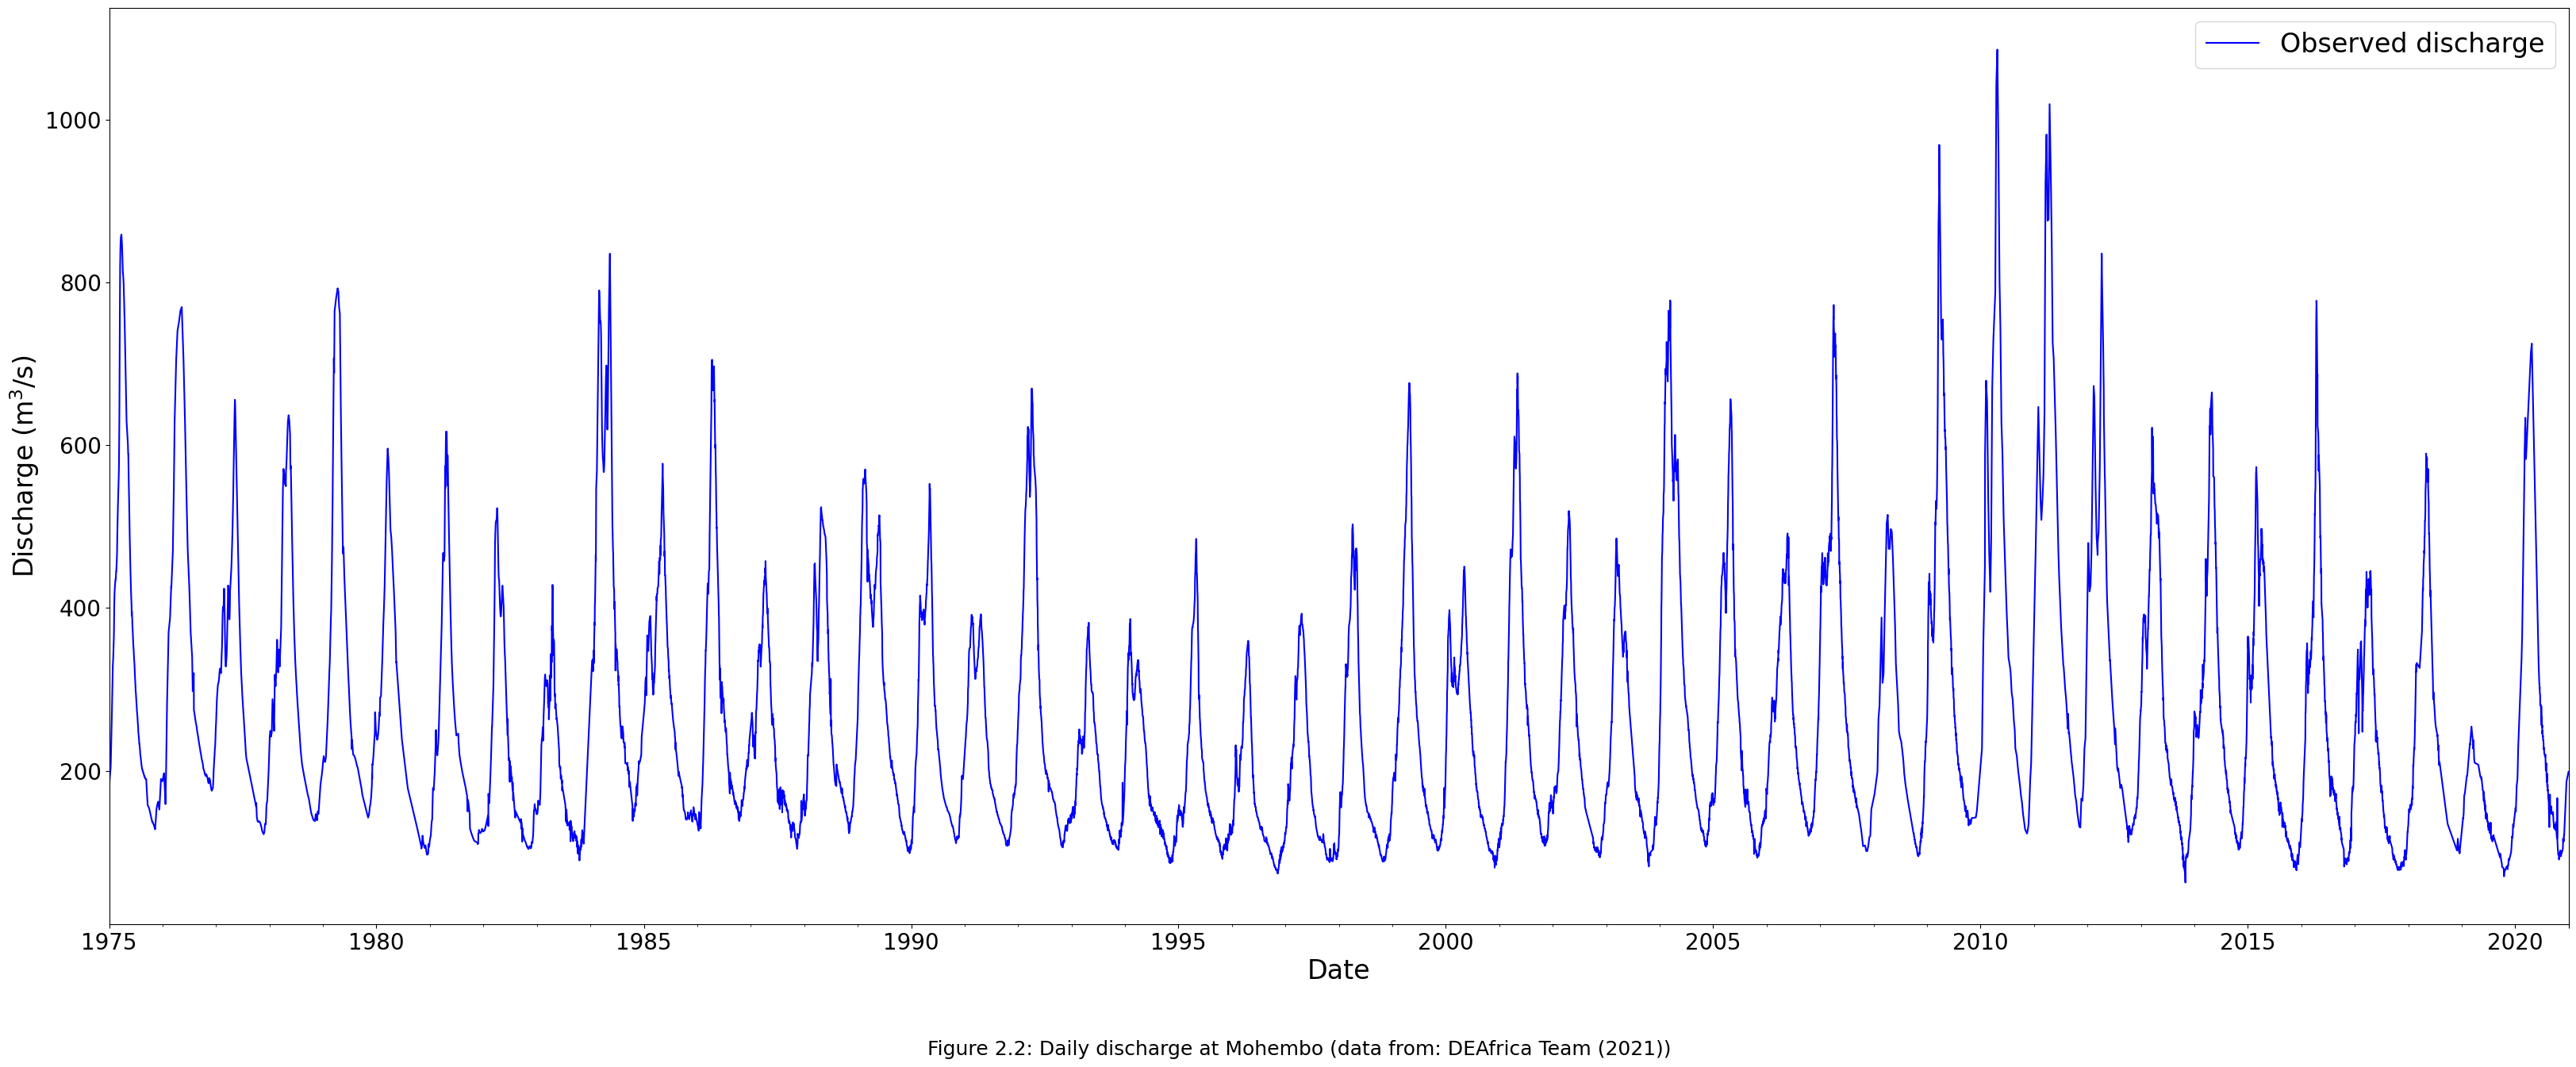

In [2]:
#Loading discharge data
data = pd.read_csv(Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/mohembo_daily_water_discharge_data.csv", 
                   index_col='date', parse_dates=True, dayfirst=True)

#Years with missing data will not lower yearly volume because of the missing data
data_daily = data.resample('D').interpolate() 
data_daily.columns = ['Observed discharge']

#Excluding years without measurements troughout the whole year
data_daily = data_daily[~data_daily.index.year.isin([1974, 2021])] 

#Plotting daily discharge data
fig, ax = plt.subplots(figsize=(40, 15))
data_daily.plot(ax=ax, color='blue')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m$^3$/s)", fontsize=24)
plt.legend(fontsize=24)
fig.text(0.5, 0,"Figure 2.2: Daily discharge at Mohembo (data from: DEAfrica Team (2021))", ha="center", fontsize=18);

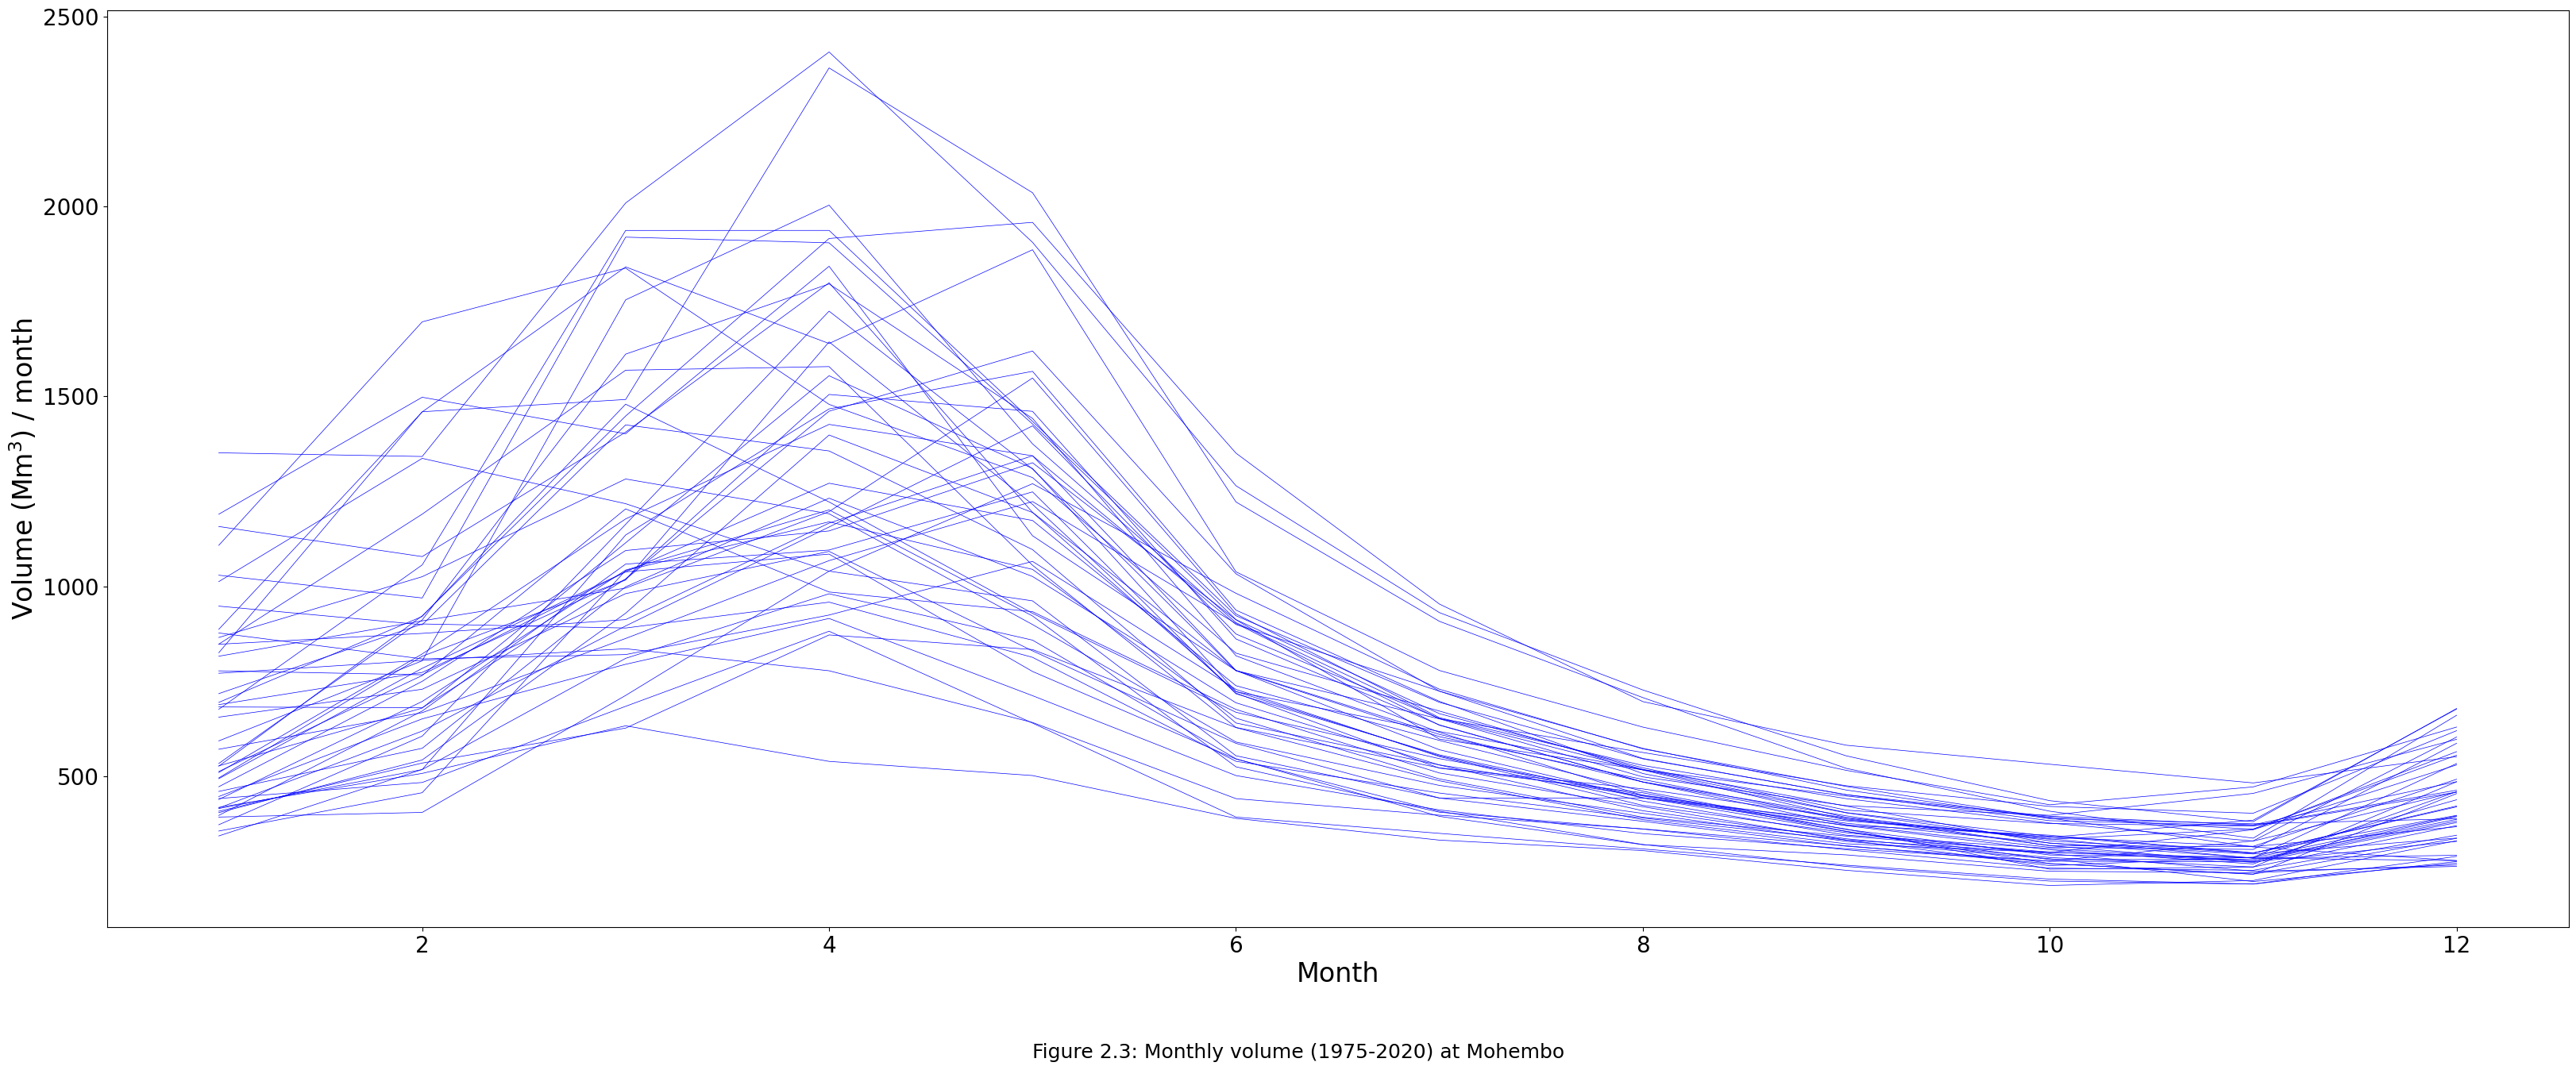

In [3]:
#Convert daily discharge in m^3/s to monthly volume in Mm^3
data_monthly = (data_daily * 3600 * 24).resample('ME').sum() / 1e6 
data_monthly.index = data_monthly.index.month
data_monthly.columns = ['Monthly volume (Mm$^3$ / month)']

#Plotting monthly volume data
fig, ax = plt.subplots(figsize=(40, 15))

#To get rid of the lines connecting December to January
for i in range(len(data_monthly) // 12):
    data_plotted = data_monthly[i * 12 : 12 + i * 12]
    data_plotted.plot(ax=ax, linewidth=0.5, color='blue', legend=False)
    
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Month", fontsize=24)
ax.set_ylabel("Volume (Mm$^3$) / month", fontsize=24)
fig.text(0.5, 0,"Figure 2.3: Monthly volume (1975-2020) at Mohembo", ha="center", fontsize=18);

Figure 2.4 shows the total yearly volume (left axis) and the volume between February and July (right axis) – that causes the flood plains – that is measured at Mohembo. This study will look at the total yearly volume that the Okavango Delta receives from the river, as it is closely related to the total volume during the flooding period.

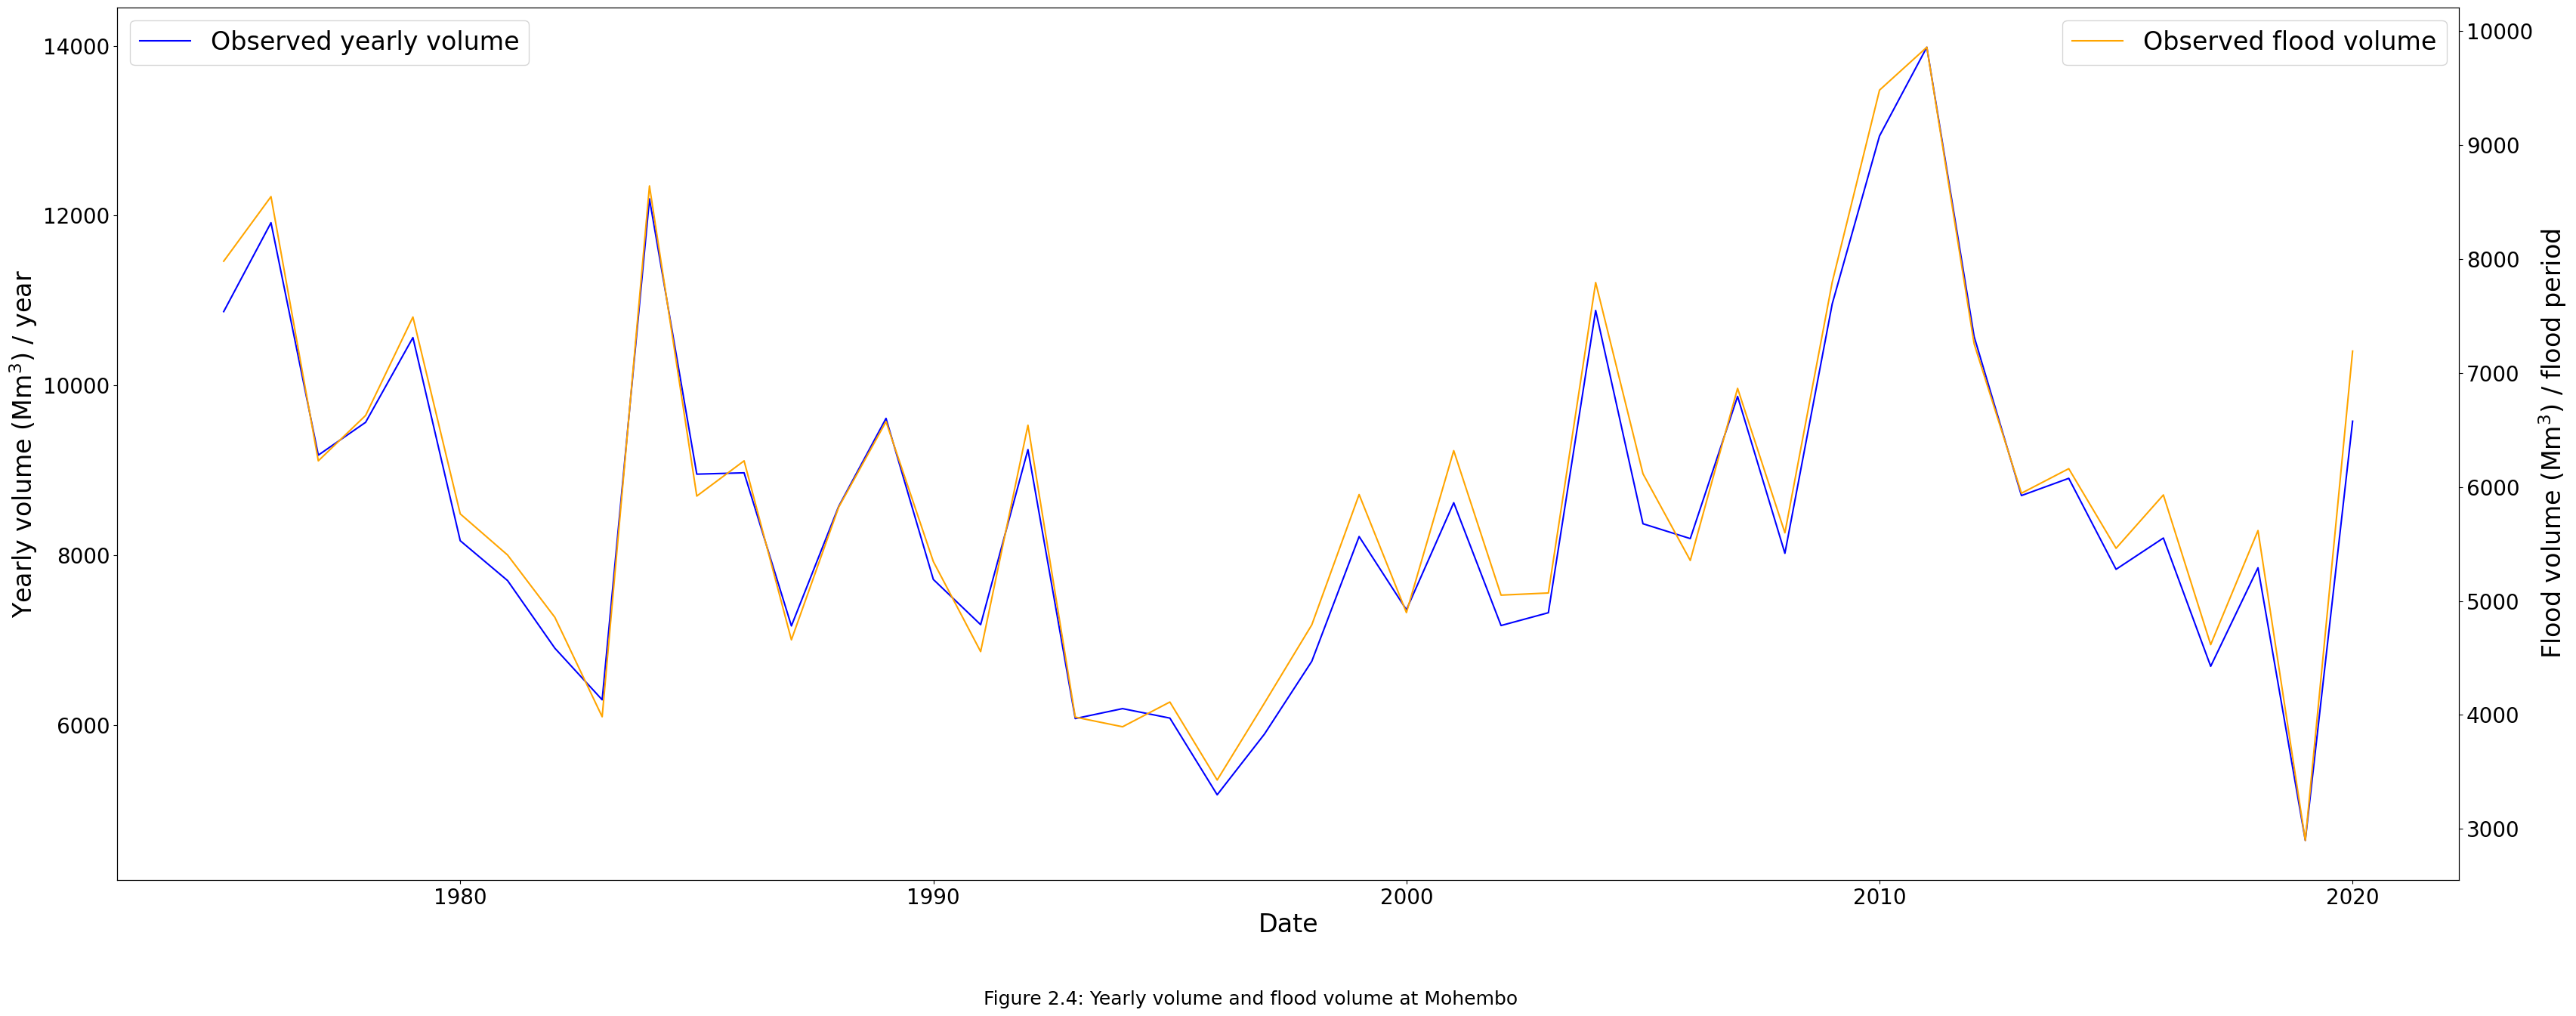

In [4]:
#Convert daily discharge in m^3/s to yearly volume in Mm^3 
yearly_volume = (data_daily * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume.index = yearly_volume.index.year
yearly_volume.columns = ['Observed yearly volume']

#Convert daily discharge in m^3/s to monthly volume in Mm^3 in the months February to July
flood_volume = (data_daily * 3600 * 24)[data_daily.index.month.isin([2,3,4,5,6,7])].resample("YE").sum() / 1e6
flood_volume.index = flood_volume.index.year
flood_volume.columns = ['Observed flood volume']

#Plotting yearly volume and flood volume
fig, ax = plt.subplots(figsize=(40, 15))
yearly_volume.plot(ax=ax, color='blue')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=24, loc='upper left')

#Seperate y-axis for flood volume on the right side
ax1 = ax.twinx()
flood_volume.plot(ax=ax1, color='orange')
plt.yticks(fontsize=20)
plt.legend(fontsize=24, loc='upper right')

ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Yearly volume (Mm$^3$) / year", fontsize=24)
ax1.set_ylabel("Flood volume (Mm$^3$) / flood period", fontsize=24)
fig.text(0.5, 0,"Figure 2.4: Yearly volume and flood volume at Mohembo", ha="center", fontsize=18);

In this study, years are considered dry if the total yearly volume of the Okavango River at Mohembo falls below the historical 15th percentile threshold. This corresponds to an annual volume of 6591 Mm3/y. For reverence, the Okavango River supplies the delta with approximately 10,000 Mm3/y of water on an annual basis (Andersson, et al., 2003). In figure 2.5, the total yearly volume is shown with the 15th percentile threshold value and the years that do not meet this threshold are shown in table 2.1. The 15th percentile is selected because it captures the lowest yearly incoming volumes visible in figure 2.5. Higher percentiles also capture years that have not experienced major drought, while lower percentiles only capture the most extreme dry years.

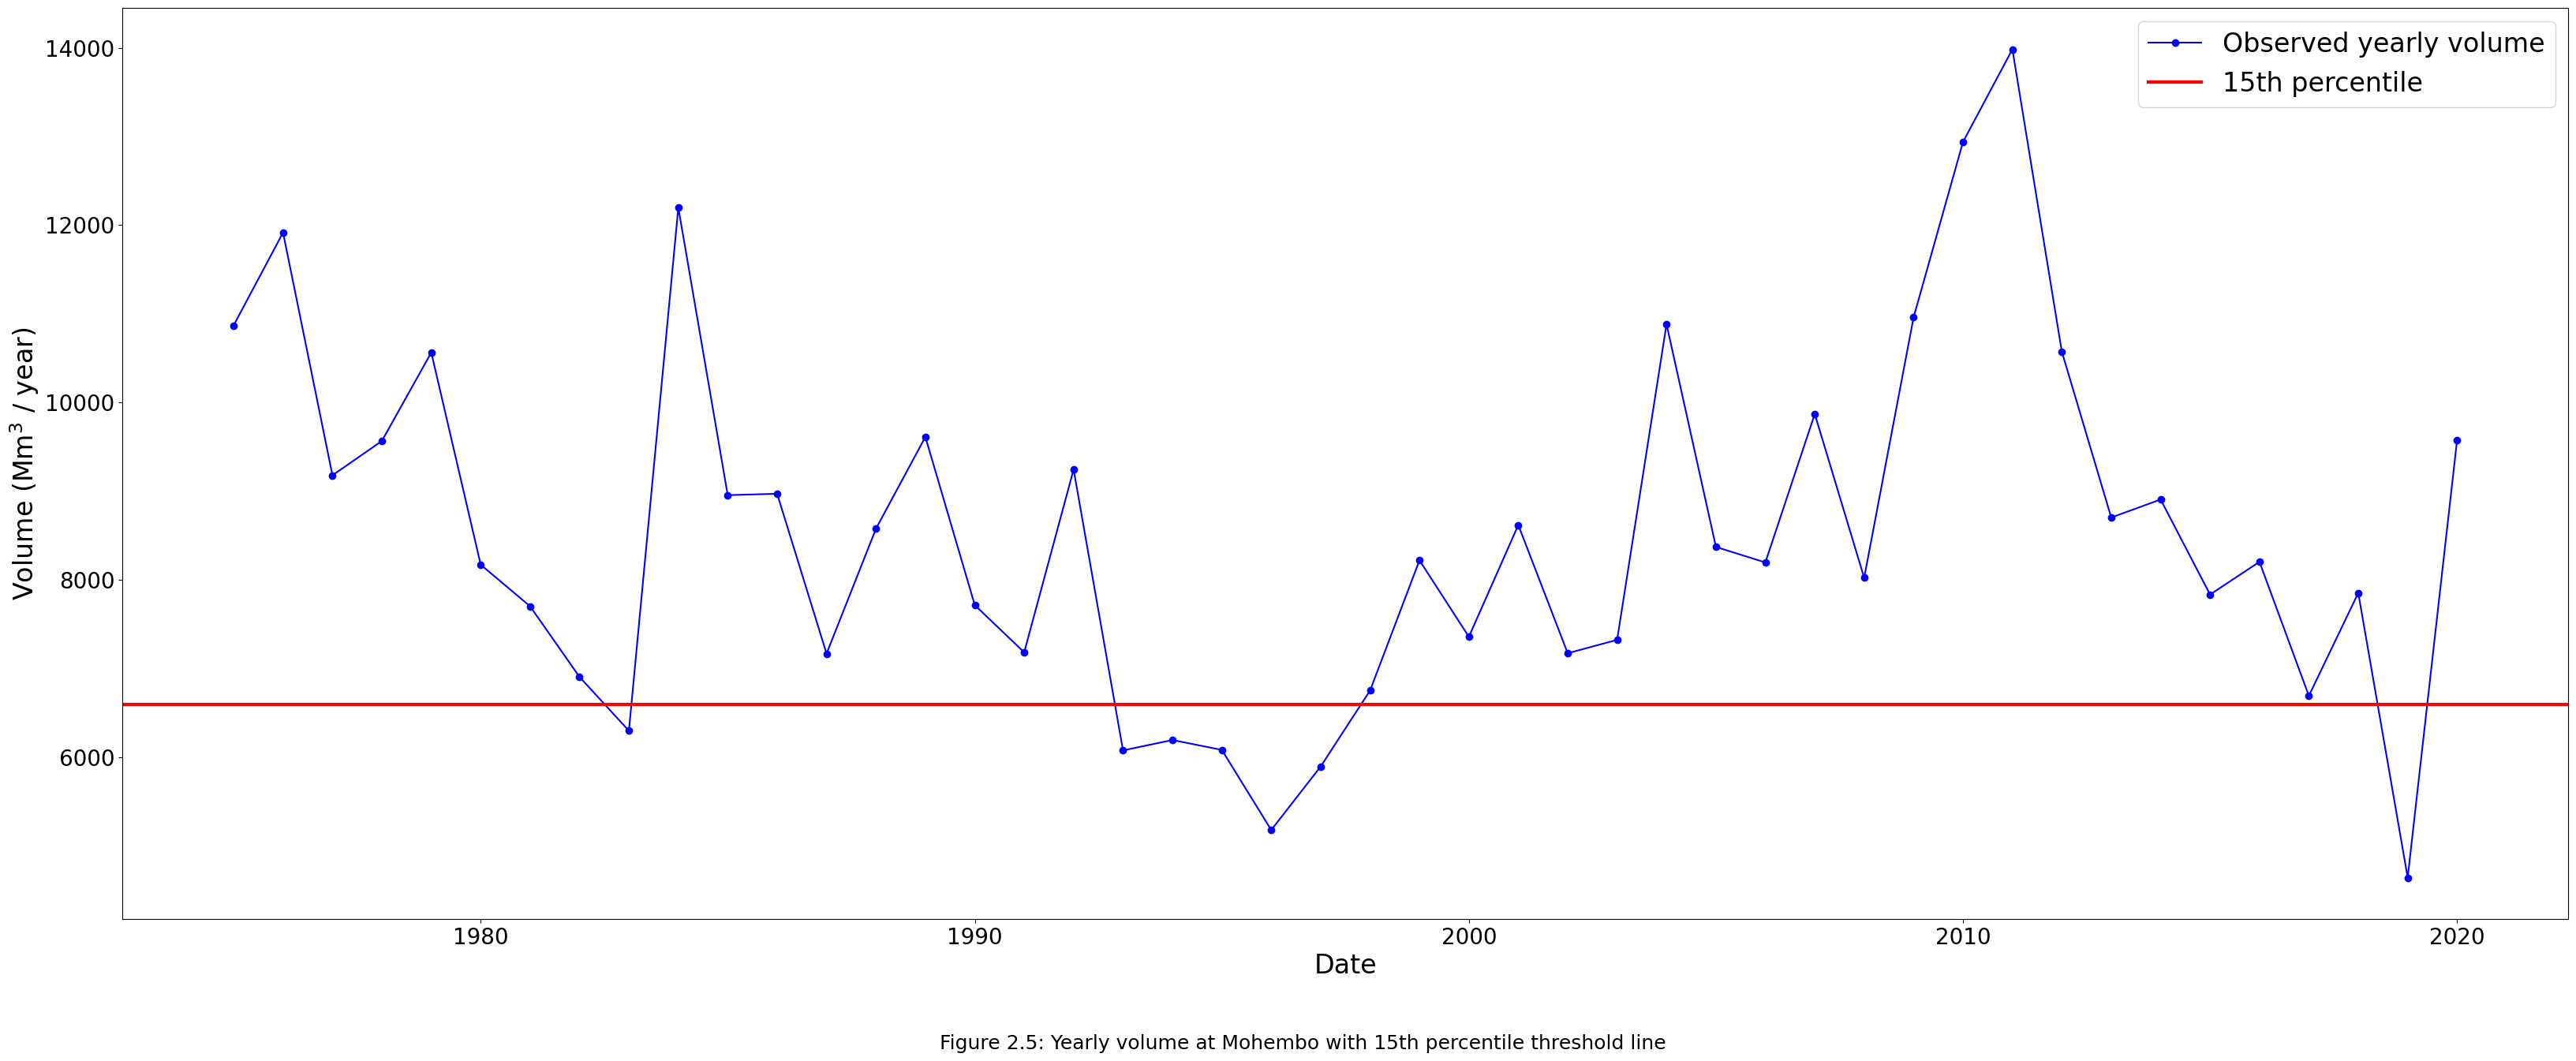

In [5]:
#Plotting yearly volume with 15th percentile line
fig, ax = plt.subplots(figsize=(40, 15))
yearly_volume.plot(ax=ax, marker='o', color='blue')
plt.axhline(y=np.percentile(yearly_volume['Observed yearly volume'], 15), color='red', linewidth=3, label='15th percentile')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Volume (Mm$^3$ / year)", fontsize=24)
plt.legend(fontsize=24)
fig.text(0.5, 0,"Figure 2.5: Yearly volume at Mohembo with 15th percentile threshold line ", ha="center", fontsize=18);

In [6]:
#Computing years that fall below the 15th percentile threshold
percentile15 = np.percentile(yearly_volume, 15)
drought_years = yearly_volume[yearly_volume['Observed yearly volume'] < percentile15]

|**Year**              |**Yearly volume (Mm$^3$)**            |
|----------------------|--------------------------------------|
|1983                  |6295                                  |
|1993                  |6074                                  |
|1994                  |6191                                  |
|1995                  |6079                                  |
|1996                  |5176                                  |
|1997                  |5892                                  |
|2019                  |4639                                  |

<div align="center">
<i>Table 2.1: Years that do not meet threshold value</i>
</div>

## 2.2 Connecting result to historical events
As mentioned in the introduction, the Okavango River supplies about 75% of the Okavango Delta’s water supply (Hamandawana, et al., 2007). Due to the majority of the water supply of the delta coming from the river, the discharge data of the river can be connected to the dry years in the Okavango Delta. In table 2.2, both the dry years and years with big floodings from news articles are shown. These years can also be seen in figure 2.5, where dry years have a yearly volume that falls below the threshold line and the years with good flooding sitting above the threshold line.

|                   |**Year(s)**              |**Elaboration**               |**Source**             |
|-------------------|-------------------------|------------------------------|-----------------------|
|**Droughts**       |1983                   |Bare ground, due to insufficient water for plant growth. The wildlife could not graze.| (Hamandawana, et al., 2007)|
|                   |1990s                  |Significant decrease in wildlife populations in the delta due droughts|(Mail & Guardian, 2011)|
|                   |2019                   |One of the worst observed droughts in the delta |(Bhuiyan, 2019)|
|**Big floodings**  |1984                   |Largest floods up to that point |(Expert Africa, 2026) |
|                   |2010 - 2012            |Largest floods in recent memory | (Okavango Delta, 2026) |

<div align="center">
<i>Table 2.2: Years of droughts and big floodings on record</i>
</div>

To conclude, the discharge data at Mohembo can be used as an indicator for dry periods in the Okavango Delta because the lows and highs in the yearly volumes can be connected with historical events.

## 2.3 Drought categories
Based on different percentiles, the droughts will be categorized into three levels: moderate, severe, and extreme. In table 2.3, the ranges for the different categories are given and the historical dry years have been given a drought level.

In [7]:
#Calculating different percentiles
percentile15 = np.percentile(yearly_volume, 15)
percentile10 = np.percentile(yearly_volume, 10)
percentile5 = np.percentile(yearly_volume, 5)

#Catogorize dry years according to the percentiles
moderate_years = yearly_volume[(yearly_volume['Observed yearly volume'] < percentile15) 
                    & (yearly_volume['Observed yearly volume'] > percentile10)]
severe_years = yearly_volume[(yearly_volume['Observed yearly volume'] < percentile10) 
                    & (yearly_volume['Observed yearly volume'] > percentile5)]
extreme_years = yearly_volume[yearly_volume['Observed yearly volume'] < percentile5]

|**Level**      |**Percentile**    |**Yearly volume range (Mm$^3$)**   |**Years**        |
|-------------- |------------------|-----------------------------------|-----------------|
|Moderate       |Q15               |6135 - 6591                        |1983, 1994       |
|Severe         |Q10               |5937 - 6135                        |1993, 1995       |
|Extreme        |Q5                |< 5937                             |1996, 1997, 2019 |

<div align="center">
<i>Table 2.2: drought categories</i>
</div>